# Proyecto entrega 1: Análisis de Alquileres en la Provincia de Madrid

> **Versión para portfolio.** Trabajo académico de David Díaz Vílchez. Las salidas conservadas proceden de la entrega original; no se han reejecutado los entrenamientos al preparar el repositorio. Se han retirado muestras de anuncios, metadatos de sesión y salidas de infraestructura. Consulta `../docs/resultados.md` y `../docs/reproduccion.md`.


In [ ]:
# Importar librerías necesarias
import pandas as pd

# Leer el archivo CSV
df = pd.read_csv('../data/20221108_1667901786.csv')

# Muestra las primeras filas para comprobar que está cargado correctamente
df.head()

# 1. Comprensión del negocio (CRISP-DM)

El proyecto tiene como objetivo analizar el mercado y la situacion de los alquileres de las viviendas en Madrid a partir del dataset disponible. Con este análisis podremos ver los patrones de comportamiento en el precio de alquiler y analizar cómo influyen en él, algunos factores como la localización, el tamaño o el número de habitaciones.

Este análisis puede ser de gran utilidad para:

*   Personas que buscan alquilar una vivienda, permitiendoles encontrar las mejores opciones adaptadas a sus necesidades.
*   Empresas inmobiliarias o propietarios, que podrán obtener valoraciones más objetivas.
*   Administraciones públicas lo podran usar para detectar desigualdades territoriales en los precios de alquiler.

# 2. Consideraciones de uso responsable

El ejercicio plantea transparencia, privacidad, análisis de sesgos y supervisión humana como criterios de diseño. Estas reflexiones académicas no acreditan cumplimiento normativo ni constituyen una evaluación jurídica.

# 3. Comprensión de los datos (CRISP-DM)

El dataset utilizado contiene información de las ofertas de alquiler de viviendas en Madrid. Dispone de un total de 9229 registros y 32 variables.

Se pueden destacar alguna variables como:


*   price: Precio del alquiler (variable objetivo para futuras predicciones).
*   district, subdistrict, location: Ubicación de la vivienda.
*   floor_area: Superficie en metros cuadrados.
*   bedrooms, bathrooms: Número de habitaciones y baños.
*   year_built: Año de construcción de la vivienda.


Tambien hay otras variables adicionales pero de menor importancia como: ascensor, piscina, terraza, garaje, aire acondicionado, cocina equipada, etc.

En el primer análisis han salido algunos valores nulos en variables como floor_area, year_built, orientation o deposit, en las siguientes fases se deberá ahcer una limpieza de datos.

El análisis inicial tambien muestra una distribución de precios del alquiler la cual se concentra sobre todo entre 500 € y 2000 €, aunque existen valores atípicos de hasta 25.000 €. También se observa una gran variabilidad de precios según el distrito, lo que confirma la importancia del análisis geográfico en el mercado inmobiliario.

In [ ]:
# Tamaño del dataset
print("Número de filas y columnas:", df.shape)

# Tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)

# Valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

Número de filas y columnas: (9229, 32)

Tipos de datos:
web_id                 int64
url                   object
title                 object
type                  object
price                  int64
deposit              float64
private_owner           bool
professional_name     object
floor_built            int64
floor_area           float64
floor                 object
year_built           float64
orientation           object
bedrooms               int64
bathrooms              int64
second_hand             bool
lift                    bool
garage_included         bool
furnished               bool
equipped_kitchen        bool
fitted_wardrobes        bool
air_conditioning        bool
terrace                 bool
balcony                 bool
storeroom               bool
swimming_pool           bool
garden_area             bool
location              object
district              object
subdistrict           object
postalcode           float64
last_update           object
dtype: object

V

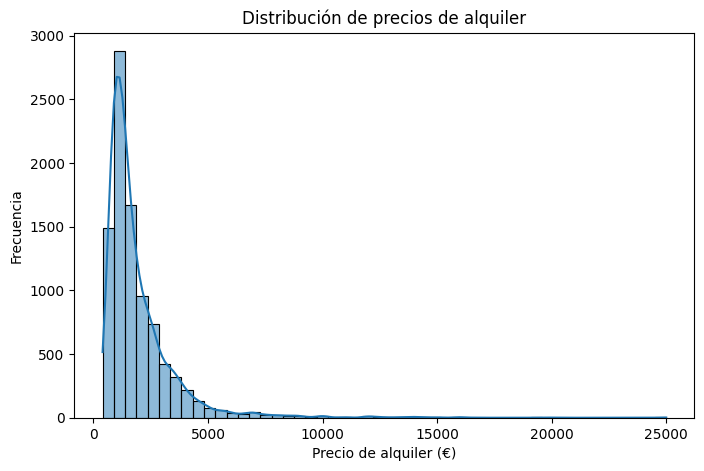

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de la variable price
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribución de precios de alquiler')
plt.xlabel('Precio de alquiler (€)')
plt.ylabel('Frecuencia')
plt.show()

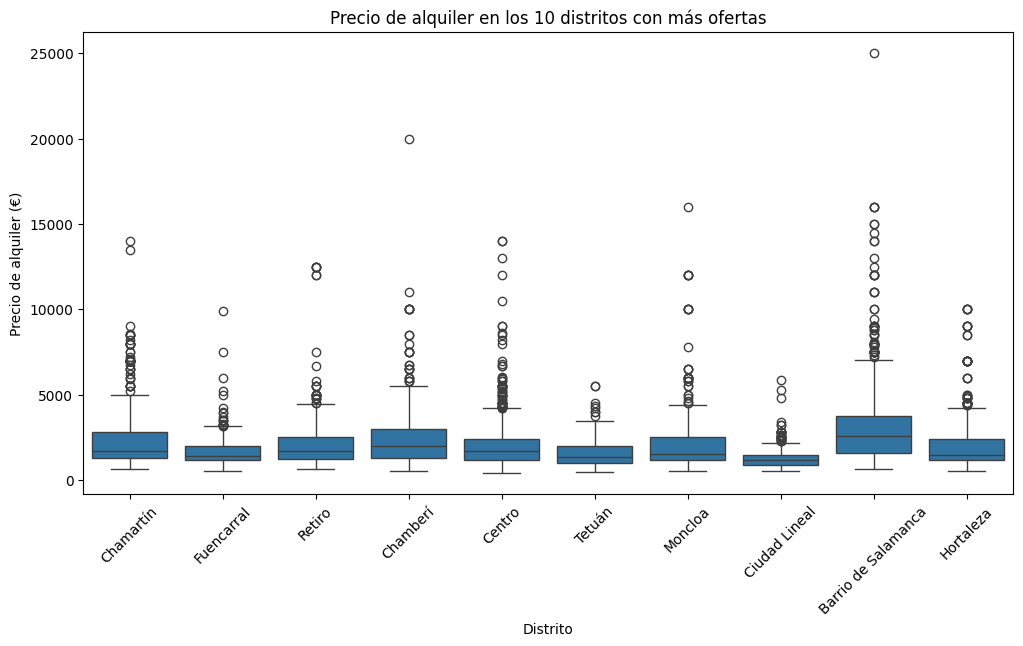

In [ ]:
# Como hay demasiados distritos acotaremos sacando los distritos mas frecuentes, en este caso analizaremos 10
top_districts = df['district'].value_counts().head(10).index

# Filtrar el dataframe para quedarnos solo con esos 10 distritos
df_top = df[df['district'].isin(top_districts)]

# Boxplot solo con esos 10 distritos
plt.figure(figsize=(12,6))
sns.boxplot(x='district', y='price', data=df_top)
plt.xticks(rotation=45)
plt.title('Precio de alquiler en los 10 distritos con más ofertas')
plt.xlabel('Distrito')
plt.ylabel('Precio de alquiler (€)')
plt.show()

# 4. Propuestas de innovación ética con IA

Se proponen como posibles líneas futuras una estimación explicable del alquiler, recomendaciones de viviendas y análisis territorial de precios. No están implementadas en esta entrega. Su desarrollo exigiría estudiar la calidad de los datos, los posibles sesgos y las condiciones de uso.

# 5. Conclusiones

El análisis inicial realizado sobre el dataset de alquileres de la provincia de Madrid ha permitido:


*   Comprender las variables principales que afectan al precio de los alquileres.
*   Detectar la presencia de valores extremos y la variabilidad por distrito.
*   Confirmar la utilidad del dataset para el desarrollo futuro de modelos de IA.